Dataset Preview:
   id        age  gender  height  weight  ap_hi  ap_lo        cholesterol  \
0   0  50.357290    male     168    62.0    110     80             normal   
1   1  55.381246  female     156    85.0    140     90  well above normal   
2   2  51.627652  female     165    64.0    130     70  well above normal   
3   3  48.249144    male     169    82.0    150    100             normal   
4   4  47.841205  female     156    56.0    100     60             normal   

     gluc  smoke   alco  active  cardio        bmi age_group  \
0  normal  False  False    True   False  21.967120     50-59   
1  normal  False  False    True    True  34.927679     50-59   
2  normal  False  False   False    True  23.507805     50-59   
3  normal  False  False    True    True  28.710479     40-49   
4  normal  False  False   False   False  23.011177     40-49   

            bp_category  
0              elevated  
1  stage 2 hypertension  
2  stage 1 hypertension  
3  stage 2 hypertension  
4    

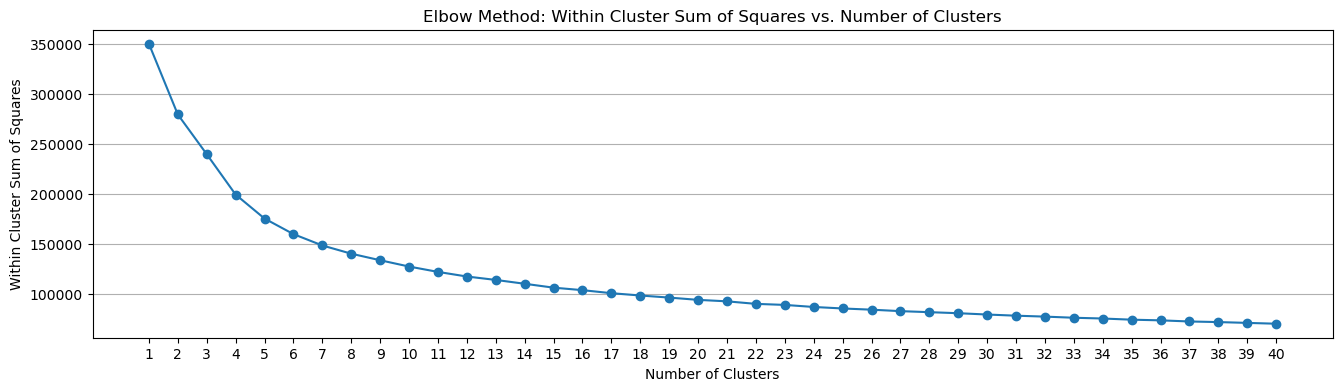

Cluster Centers (in Original Scale):
Cluster 0:  46.55	165.67	69.79	116.21	76.6
Cluster 1:  55.17	168.92	88.2	140.11	87.56
Cluster 2:  54.36	164.3	80.77	154.59	198.29
Cluster 3:  57.69	159.9	67.35	125.07	80.67

Within Cluster Sum of Squares: 199077.06833198137


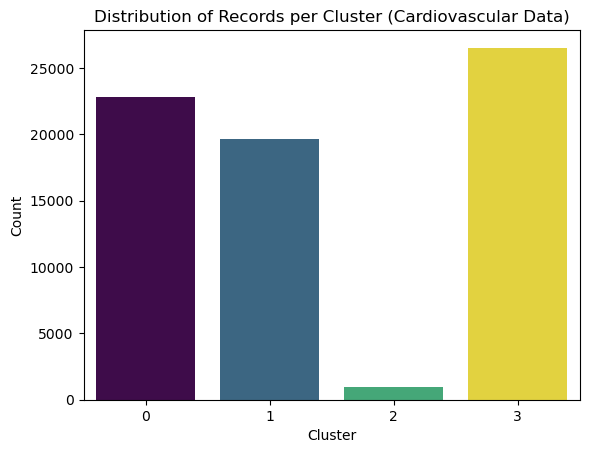

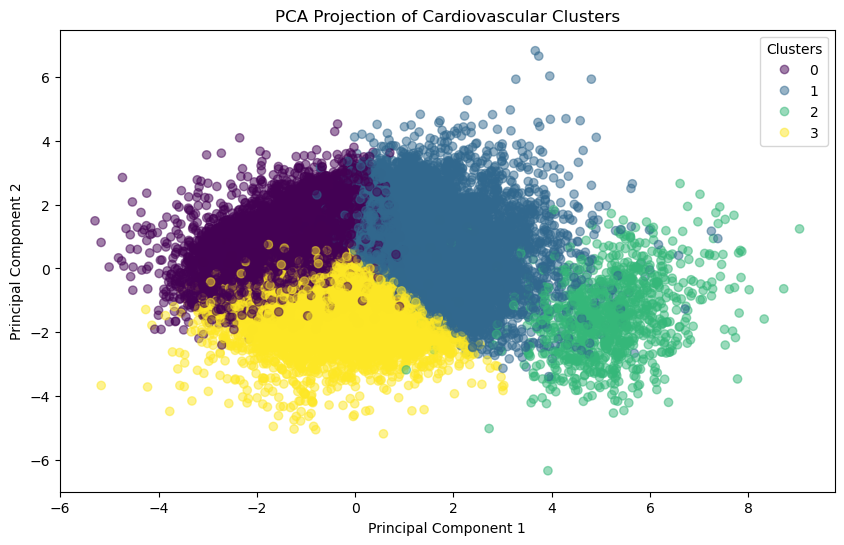

<Figure size 1600x600 with 0 Axes>

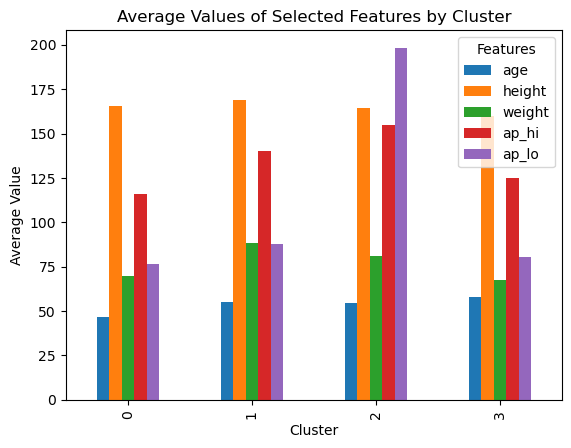

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------
# Step 1. Load the Cardiovascular Dataset
# ---------------------------------------------

df = pd.read_csv('combined_cleaned_cardio_data.csv')

# Inspect the data briefly
print("Dataset Preview:")
print(df.head())
print("\nDataset Info:")
print(df.info())

# ---------------------------------------------
# Step 2. Select Continuous Features for Clustering
# ---------------------------------------------
# For the cardiovascular dataset, we select:
# - "age" (often in days; you may convert to years if needed)
# - "height" (in centimeters)
# - "weight" (in kilograms)
# - "ap_hi" (systolic blood pressure)
# - "ap_lo" (diastolic blood pressure)
features = ["age", "height", "weight", "ap_hi", "ap_lo"]
X = df[features]

# ---------------------------------------------
# Step 3. Scale the Features
# ---------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------
# Step 4. Vary the Number of Clusters (Elbow Method)
# ---------------------------------------------
min_clust = 1
max_clust = 40
init_algo = 'k-means++'
within_ss = []

for num_clust in range(min_clust, max_clust + 1):
    kmeans = KMeans(n_clusters=num_clust, init=init_algo, n_init=5, random_state=42)
    kmeans.fit(X_scaled)
    within_ss.append(kmeans.inertia_)

# Plot the Elbow Plot: Within Cluster Sum of Squares vs. Number of Clusters
plt.figure(figsize=(16, 4))
plt.plot(range(min_clust, max_clust + 1), within_ss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Within Cluster Sum of Squares')
plt.xticks(np.arange(min_clust, max_clust + 1, 1))
plt.title("Elbow Method: Within Cluster Sum of Squares vs. Number of Clusters")
plt.grid(which='major', axis='y')
plt.show()

# ---------------------------------------------
# Step 5. Fit the Optimized KMeans++ Model
# ---------------------------------------------
# For demonstration, we select 4 clusters based on the Elbow Plot.
num_clusters = 4

kmeans = KMeans(n_clusters=num_clusters,
                init=init_algo,
                n_init=20,
                random_state=42)
kmeans.fit(X_scaled)

# Print the cluster centers after converting them back to the original scale.
print("Cluster Centers (in Original Scale):")
for i, center in enumerate(kmeans.cluster_centers_):
    # Reshape from 1D to 2D before inverse transforming:
    center_original = scaler.inverse_transform(center.reshape(1, -1))[0]
    print(f"Cluster {i}: ", "\t".join([str(round(val, 2)) for val in center_original]))

print("\nWithin Cluster Sum of Squares:", kmeans.inertia_)

# ---------------------------------------------
# Step 6. Label Data and Visualize the Clusters
# ---------------------------------------------
# Predict the cluster labels and append them to the DataFrame
labels = kmeans.predict(X_scaled)
df["Cluster"] = labels

# (a) Count Plot: Display the number of records per cluster.
# To avoid the FutureWarning, we assign 'Cluster' to both x and hue and then remove the legend.
ax = sns.countplot(x="Cluster", hue="Cluster", data=df, palette="viridis")
ax.legend_.remove()  # Remove the legend for clarity
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.title("Distribution of Records per Cluster (Cardiovascular Data)")
plt.show()

# (b) PCA Visualization: Project the high-dimensional data to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", alpha=0.5)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Cardiovascular Clusters")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()

# (c) Bar Plot: Display the average feature value for each cluster
cluster_data = df.groupby("Cluster")[features].mean()
plt.figure(figsize=(16, 6))
cluster_data.plot(kind='bar')
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.title("Average Values of Selected Features by Cluster")
plt.legend(title="Features")
plt.show()
